# Mode Choice Prediction in Switzerland

## Reading the dataset

The data is presented as `txt` file, with tabulated columns.


In [2]:
import pandas as pd

dataset = pd.read_csv("ModeChoiceOptima.txt", sep="\t")

dataset

,ID,DestAct,NbTransf,TimePT,WalkingTimePT,WaitingTimePT,CostPT,CostCar,TimeCar,NbHousehold,...,FreqTripHouseh,Region,distance_km,Choice,InVehicleTime,ModeToSchool,ReportedDuration,CoderegionCAR,age,Weight
0,10350017,2,4,85,23,10,12.4,3.17,32,2,...,4,1,30.0,1,52,3,255,1,27,0.000379
1,10350020,1,4,108,26,16,12.4,3.28,30,2,...,4,1,32.0,-1,66,3,150,1,28,0.000341
2,10350025,11,2,82,33,5,3.0,0.45,6,-1,...,2,1,4.5,0,44,-1,20,1,-1,0.000368
3,10350075,1,3,107,21,31,24.0,2.36,23,2,...,1,1,25.0,1,55,-1,30,1,63,0.000368
4,10350085,1,5,190,116,18,10.8,1.16,14,3,...,3,1,12.5,1,56,-1,20,1,57,0.000409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260,96040535,1,6,299,84,94,48.8,10.72,86,1,...,1,7,119.0,-1,121,6,90,7,51,0.000409
2261,96040537,8,0,139,116,0,14.4,3.18,43,5,...,3,7,32.0,1,23,5,70,7,46,0.000368
2262,96040537,8,0,71,57,0,6.0,0.94,12,5,...,3,7,9.0,1,14,5,20,7,46,0.000368
2263,96040538,11,2,118,70,10,11.4,1.77,24,5,...,4,7,17.5,1,38,3,30,7,49,0.000409


Five different datasets are to be analyzed, based on:

1. Structural features
2. Socio-economics features
3. Attitudinal features
4. All of the above


### Create Training & Validation Data


In [3]:
from enum import Enum


class FeatureType(Enum):
    Numerical = 1
    Ordinal = 2
    Nominal = 3


structural_features = [
    ("NbTransf", FeatureType.Numerical),
    ("TimePT", FeatureType.Numerical),
    ("WalkingTimePT", FeatureType.Numerical),
    ("WaitingTimePT", FeatureType.Numerical),
    ("TimeCar", FeatureType.Numerical),
    ("CostPT", FeatureType.Numerical),
    ("MarginalCostPT", FeatureType.Numerical),
    ("CostCar", FeatureType.Numerical),
    ("TripPurpose", FeatureType.Nominal),
    ("TypeCommune", FeatureType.Nominal),
    ("ClassifCodeLine", FeatureType.Nominal),
    ("frequency", FeatureType.Ordinal),
    ("NbTrajects", FeatureType.Numerical),
    ("distance_km", FeatureType.Numerical),
    ("DestAct", FeatureType.Nominal),
    ("FreqTripHouseh", FeatureType.Ordinal),
]

socio_features = [
    ("age", FeatureType.Numerical),
    ("ModeToSchool", FeatureType.Nominal),
    ("ResidChild", FeatureType.Nominal),
    ("NbHousehold", FeatureType.Numerical),
    ("NbChild", FeatureType.Numerical),
    ("NbCar", FeatureType.Numerical),
    ("NbMoto", FeatureType.Numerical),
    ("NbBicy", FeatureType.Numerical),
    ("NbBicyChild", FeatureType.Numerical),
    ("NbComp", FeatureType.Numerical),
    ("NbTV", FeatureType.Numerical),
    ("Internet", FeatureType.Nominal),
    ("NewsPaperSubs", FeatureType.Nominal),
    ("NbCellPhones", FeatureType.Numerical),
    ("NbSmartPhone", FeatureType.Numerical),
    ("HouseType", FeatureType.Nominal),
    ("Income", FeatureType.Ordinal),
    ("Gender", FeatureType.Nominal),
    ("Mothertongue", FeatureType.Nominal),
    ("FamilSitu", FeatureType.Nominal),
    ("OccupStat", FeatureType.Nominal),
    ("SocioProfCat", FeatureType.Nominal),
    ("Education", FeatureType.Ordinal),
]

attitudinal_features = [
    ("Envir01", FeatureType.Ordinal),
    ("Envir02", FeatureType.Ordinal),
    ("Envir03", FeatureType.Ordinal),
    ("Envir04", FeatureType.Ordinal),
    ("Envir05", FeatureType.Ordinal),
    ("Envir06", FeatureType.Ordinal),
    ("Mobil01", FeatureType.Ordinal),
    ("Mobil02", FeatureType.Ordinal),
    ("Mobil03", FeatureType.Ordinal),
    ("Mobil04", FeatureType.Ordinal),
    ("Mobil05", FeatureType.Ordinal),
    ("Mobil06", FeatureType.Ordinal),
    ("Mobil07", FeatureType.Ordinal),
    ("Mobil08", FeatureType.Ordinal),
    ("Mobil09", FeatureType.Ordinal),
    ("Mobil10", FeatureType.Ordinal),
    ("Mobil11", FeatureType.Ordinal),
    ("Mobil12", FeatureType.Ordinal),
    ("Mobil13", FeatureType.Ordinal),
    ("Mobil14", FeatureType.Ordinal),
    ("Mobil15", FeatureType.Ordinal),
    ("Mobil16", FeatureType.Ordinal),
    ("Mobil17", FeatureType.Ordinal),
    ("Mobil18", FeatureType.Ordinal),
    ("Mobil19", FeatureType.Ordinal),
    ("Mobil20", FeatureType.Ordinal),
]

global_features = structural_features + socio_features + attitudinal_features

df = dataset[[f for f, _ in global_features] + ["Choice"]]

# Drop all rows with missing values
drop_features = 0
for feature, _ in global_features + [("Choice", FeatureType.Nominal)]:
    missing = df[feature] < 0
    df.drop(df[missing].index, inplace=True)
    drop_features += missing.sum()

print(f"Dropped {drop_features} rows with missing values")
print(f"Dataset size after dropping: {len(df)}")

Dropped 1116 rows with missing values
Dataset size after dropping: 1149


In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Choice"])
y = df["Choice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  # 20% for validation
    random_state=42,
    stratify=y,  # Make sure enough samples of each class are in both sets
)

## Prepare Pipelines


In [5]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

get_preprocessor = lambda features: ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            [
                f
                for f, t in features
                if t == FeatureType.Numerical or t == FeatureType.Ordinal
            ],
        ),
        (
            "nom",
            OneHotEncoder(sparse_output=False),
            [f for f, t in features if t == FeatureType.Nominal],
        ),
    ]
)

get_pipeline = lambda features, classifier: Pipeline(
    steps=[
        ("preprocessor", get_preprocessor(features)),
        ("scaler", StandardScaler()),
        ("classifier", classifier),
    ]
)

### Multinomial Logistic Regression


In [6]:
from sklearn.linear_model import LogisticRegression

get_classifier = lambda: LogisticRegression(max_iter=10_000)

lr_structural_pipeline = get_pipeline(structural_features, get_classifier())
lr_socio_pipeline = get_pipeline(socio_features, get_classifier())
lr_attitudinal_pipeline = get_pipeline(attitudinal_features, get_classifier())
lr_global_pipeline = get_pipeline(global_features, get_classifier())

lr_structural_pipeline.fit(X_train, y_train)
lr_socio_pipeline.fit(X_train, y_train)
lr_attitudinal_pipeline.fit(X_train, y_train)
lr_global_pipeline.fit(X_train, y_train)

lr_structural_score = lr_structural_pipeline.score(X_test, y_test)
lr_socio_score = lr_socio_pipeline.score(X_test, y_test)
lr_attitudinal_score = lr_attitudinal_pipeline.score(X_test, y_test)
lr_global_score = lr_global_pipeline.score(X_test, y_test)

print(f"Structural features accuracy: {lr_structural_score:.4f}")
print(f"Socio features accuracy: {lr_socio_score:.4f}")
print(f"Attitudinal features accuracy: {lr_attitudinal_score:.4f}")
print(f"Global features accuracy: {lr_global_score:.4f}")

Structural features accuracy: 0.7870
Socio features accuracy: 0.7261
Attitudinal features accuracy: 0.8087
Global features accuracy: 0.8043


### Decision Tree Classifier


In [7]:
from sklearn.tree import DecisionTreeClassifier

get_classifier = lambda: DecisionTreeClassifier()

dt_structural_pipeline = get_pipeline(structural_features, get_classifier())
dt_socio_pipeline = get_pipeline(socio_features, get_classifier())
dt_attitudinal_pipeline = get_pipeline(attitudinal_features, get_classifier())
dt_global_pipeline = get_pipeline(global_features, get_classifier())

dt_structural_pipeline.fit(X_train, y_train)
dt_socio_pipeline.fit(X_train, y_train)
dt_attitudinal_pipeline.fit(X_train, y_train)
dt_global_pipeline.fit(X_train, y_train)

dt_structural_score = dt_structural_pipeline.score(X_test, y_test)
dt_socio_score = dt_socio_pipeline.score(X_test, y_test)
dt_attitudinal_score = dt_attitudinal_pipeline.score(X_test, y_test)
dt_global_score = dt_global_pipeline.score(X_test, y_test)

print(f"Structural features accuracy: {dt_structural_score:.4f}")
print(f"Socio features accuracy: {dt_socio_score:.4f}")
print(f"Attitudinal features accuracy: {dt_attitudinal_score:.4f}")
print(f"Global features accuracy: {dt_global_score:.4f}")

Structural features accuracy: 0.7565
Socio features accuracy: 0.6870
Attitudinal features accuracy: 0.7522
Global features accuracy: 0.7957


### XGBoost


In [8]:
from sklearn.ensemble import GradientBoostingClassifier

get_classifier = lambda: GradientBoostingClassifier()

xgboost_structural_pipeline = get_pipeline(structural_features, get_classifier())
xgboost_socio_pipeline = get_pipeline(socio_features, get_classifier())
xgboost_attitudinal_pipeline = get_pipeline(attitudinal_features, get_classifier())
xgboost_global_pipeline = get_pipeline(global_features, get_classifier())

xgboost_structural_pipeline.fit(X_train, y_train)
xgboost_socio_pipeline.fit(X_train, y_train)
xgboost_attitudinal_pipeline.fit(X_train, y_train)
xgboost_global_pipeline.fit(X_train, y_train)

xgboost_structural_score = xgboost_structural_pipeline.score(X_test, y_test)
xgboost_socio_score = xgboost_socio_pipeline.score(X_test, y_test)
xgboost_attitudinal_score = xgboost_attitudinal_pipeline.score(X_test, y_test)
xgboost_global_score = xgboost_global_pipeline.score(X_test, y_test)

print(f"Structural features accuracy: {xgboost_structural_score:.4f}")
print(f"Socio features accuracy: {xgboost_socio_score:.4f}")
print(f"Attitudinal features accuracy: {xgboost_attitudinal_score:.4f}")
print(f"Global features accuracy: {xgboost_global_score:.4f}")

Structural features accuracy: 0.8217
Socio features accuracy: 0.7043
Attitudinal features accuracy: 0.7913
Global features accuracy: 0.8826


### Neural Networks


In [9]:
from sklearn.neural_network import MLPClassifier

layers = (20, 5)

get_classifier = lambda: MLPClassifier(
    solver="lbfgs", max_iter=10_000, hidden_layer_sizes=layers, random_state=42
)

nn_structural_pipeline = get_pipeline(structural_features, get_classifier())
nn_socio_pipeline = get_pipeline(socio_features, get_classifier())
nn_attitudinal_pipeline = get_pipeline(attitudinal_features, get_classifier())
nn_global_pipeline = get_pipeline(global_features, get_classifier())

nn_structural_pipeline.fit(X_train, y_train)
nn_socio_pipeline.fit(X_train, y_train)
nn_attitudinal_pipeline.fit(X_train, y_train)
nn_global_pipeline.fit(X_train, y_train)

nn_structural_score = nn_structural_pipeline.score(X_test, y_test)
nn_socio_score = nn_socio_pipeline.score(X_test, y_test)
nn_attitudinal_score = nn_attitudinal_pipeline.score(X_test, y_test)
nn_global_score = nn_global_pipeline.score(X_test, y_test)

print(f"Structural features accuracy: {nn_structural_score:.4f}")
print(f"Socio features accuracy: {nn_socio_score:.4f}")
print(f"Attitudinal features accuracy: {nn_attitudinal_score:.4f}")
print(f"Global features accuracy: {nn_global_score:.4f}")

Structural features accuracy: 0.7522
Socio features accuracy: 0.6957
Attitudinal features accuracy: 0.7174
Global features accuracy: 0.7652


## SHAP


In [57]:
import shap

# Extract classifiers and preprocessors from pipelines
lr_preprocessor = lr_global_pipeline.named_steps["preprocessor"]
dt_preprocessor = dt_global_pipeline.named_steps["preprocessor"]
xgboost_preprocessor = xgboost_global_pipeline.named_steps["preprocessor"]
nn_preprocessor = nn_global_pipeline.named_steps["preprocessor"]

lr_classifier = lr_global_pipeline.named_steps["classifier"]
dt_classifier = dt_global_pipeline.named_steps["classifier"]
xgboost_classifier = xgboost_global_pipeline.named_steps["classifier"]
nn_classifier = nn_global_pipeline.named_steps["classifier"]

# Transform data using preprocessors
feature_names = (
    lr_preprocessor.get_feature_names_out()
)  # same for all if pipeline is identical

X_train_lr = pd.DataFrame(lr_preprocessor.transform(X_train), columns=feature_names)
X_test_lr = pd.DataFrame(lr_preprocessor.transform(X_test), columns=feature_names)

X_train_dt = pd.DataFrame(dt_preprocessor.transform(X_train), columns=feature_names)
X_test_dt = pd.DataFrame(dt_preprocessor.transform(X_test), columns=feature_names)

X_train_xgb = pd.DataFrame(
    xgboost_preprocessor.transform(X_train), columns=feature_names
)
X_test_xgb = pd.DataFrame(xgboost_preprocessor.transform(X_test), columns=feature_names)

X_train_nn = pd.DataFrame(nn_preprocessor.transform(X_train), columns=feature_names)
X_test_nn = pd.DataFrame(nn_preprocessor.transform(X_test), columns=feature_names)


# Create SHAP explainers for each model
background = shap.sample(X_train_nn, nsamples=100)

lr_explainer = shap.LinearExplainer(lr_classifier, X_train_lr)
dt_explainer = shap.TreeExplainer(dt_classifier)
xgboost_explainer = shap.KernelExplainer(xgboost_classifier.predict_proba, background)
nn_explainer = shap.KernelExplainer(nn_classifier.predict_proba, background)

shap_values_lr = lr_explainer(X_test_lr)
shap_values_dt = dt_explainer(X_test_dt)
shap_values_xgboost = xgboost_explainer(X_test_xgb)
shap_values_nn = nn_explainer(X_test_nn.values)

  0%|          | 0/230 [00:00<?, ?it/s]

  0%|          | 0/230 [00:00<?, ?it/s]

### Logistic Regression Analysis


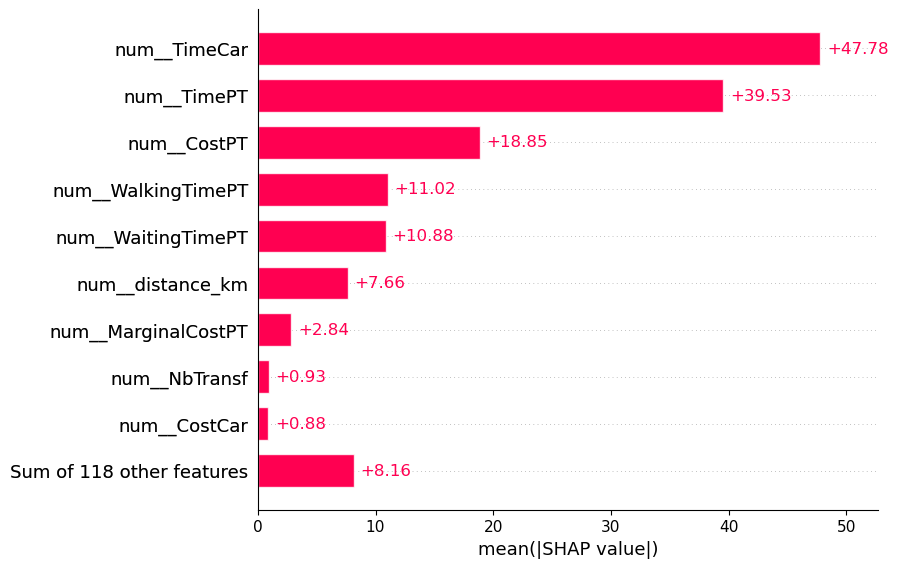

In [58]:
shap.plots.bar(shap_values_lr[:, :, 0])

### Decision Tree Analysis


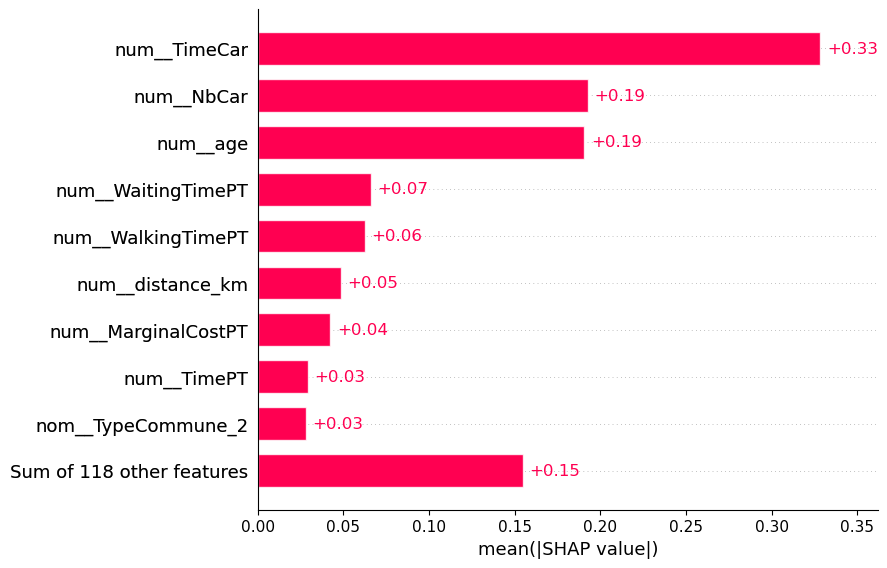

In [59]:
shap.plots.bar(shap_values_dt[:, :, 0])

### XGBoost Analysis


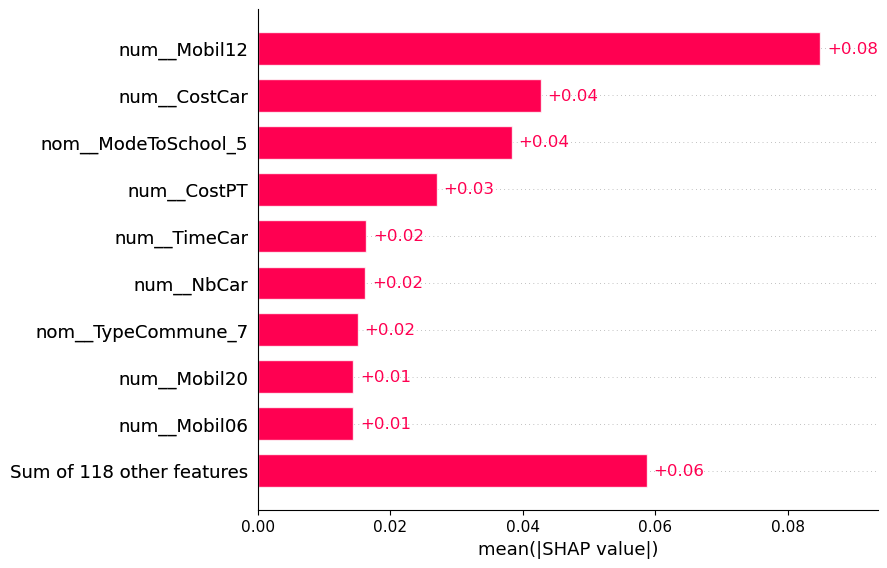

In [67]:
shap.plots.bar(shap_values_xgboost[:, :, 0])

### Neural Network Analysis


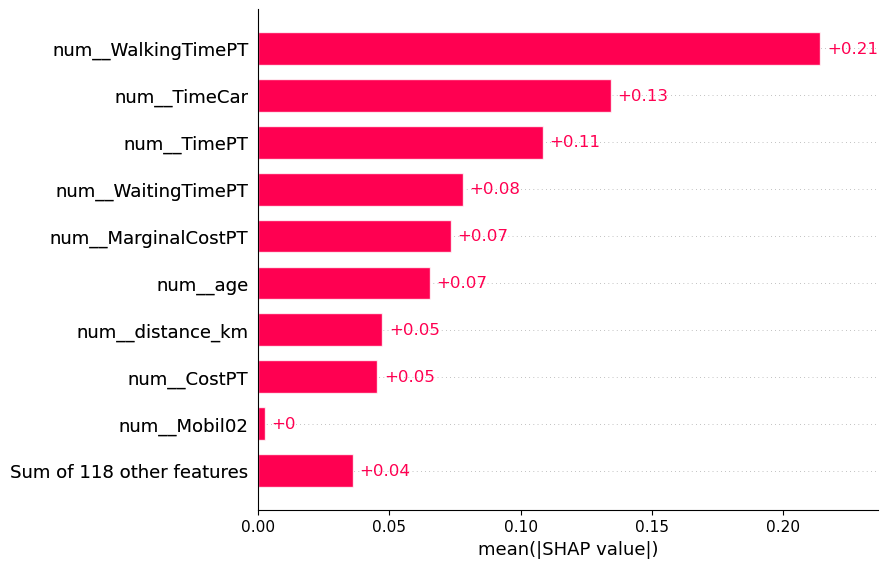

In [63]:
shap.plots.bar(shap_values_nn[:, :, 0])